# Step 3 — Specification

> Full prompt for this step, reproduced verbatim (CLAUDE.md code-style rule:
> each notebook opens with its own spec so it is self-contained).

STEP 3 — Covariance: rolling sample + Ledoit-Wolf

Read CLAUDE.md first. Implement ONLY this step, in notebooks/03_covariance.ipynb.
First cell: this entire prompt in markdown, titled "# Step 3 — Specification".

## Goal
Produce, for each month-end, the covariance matrix of the 6 OPTIMIZABLE
assets (SPY, VEA, XLE, XLU, IEF, GLD — SHY is NOT part of the optimizable
universe, see CLAUDE.md) estimated point-in-time from the trailing 3 years
of weekly returns, in two versions: raw sample and Ledoit-Wolf shrunk.
These matrices are the direct input of step 5 (optimization).

## Procedure
1. Load data/returns_weekly.parquet, keep the 6 optimizable assets.
2. Build the schedule of month-end dates. Start: first month-end where ALL
   6 assets have >= 156 weekly observations of history (this will be
   ~mid-2010 given VEA starts 2007-07). End: last full month.
3. For each month-end T:
   a. Take the trailing 156 weekly returns up to and including T
      (data through T only — point-in-time, CLAUDE.md rules 1-2).
   b. Sample covariance S_T (pandas .cov(), annualize by *52).
   c. Ledoit-Wolf Σ_T via sklearn.covariance.LedoitWolf (annualize *52).
      Record the fitted shrinkage_ delta for each T.
4. Store all matrices: outputs/cov_sample.parquet and outputs/cov_lw.parquet
   (long format: date, asset_i, asset_j, value) plus outputs/lw_delta.csv
   (date, delta).

## Diagnostics (the point of this step — print/plot clearly)
1. Time series plot of the LW shrinkage delta. Expected: small (~0.05-0.25).
   Comment on when it rises (usually after regime shifts).
2. Time series of SPY–IEF rolling correlation (from the sample matrices).
   Expected: mostly negative 2010-2021, flipping POSITIVE in 2022 (bonds
   and equity fell together — real, not a bug), possibly normalizing after.
3. Time series of average pairwise correlation among the 4 equity ETFs.
   Expected: spikes toward 1 in stress periods (2011, 2015-16, 2018, 2020,
   2022) — "diversification collapses in crises".
4. Condition number (max/min eigenvalue) of S_T vs Σ_T over time. Expected:
   LW lower and more stable. One chart, two lines.
5. For ONE illustrative date (e.g., 2020-03-31), print S vs Σ side by side
   (correlation form, 2 decimals) and highlight the largest absolute changes
   from shrinkage.

## Sanity notes
- Weekly returns only (rule 3). No optimization yet (that's step 5).
- Matrices must be symmetric positive definite; assert min eigenvalue > 0
  for every Σ_T.
- Keep it simple: loops over dates are fine, no need to vectorize.


## 0 — Setup & schedule

Load **weekly** returns (rule 3), keep the **6 optimizable** assets only — SHY is
the anchor, not part of the optimizable universe (CLAUDE.md), so it is excluded
here. We use the common sample (all 6 present, from VEA's 2007 inception) so every
trailing window is 156 complete weeks with no internal gaps.

The schedule is every month-end where at least 156 trailing weekly observations
exist, through the last full month.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from pathlib import Path

OPT6 = ["SPY", "VEA", "XLE", "XLU", "IEF", "GLD"]   # SHY excluded (anchor, not optimizable)
WINDOW = 156       # 3 years of weekly returns
ANN = 52           # weeks per year (annualization factor)

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

rw = pd.read_parquet(DATA_DIR / "returns_weekly.parquet")[OPT6].dropna()
today = pd.Timestamp.today().normalize()
month_ends = pd.date_range(rw.index.min(), today, freq="ME")   # month-ends <= today (excludes partial month)
schedule = [T for T in month_ends if (rw.index <= T).sum() >= WINDOW]

print(f"Common weekly sample: {rw.index.min().date()} -> {rw.index.max().date()} (n={len(rw)})")
print(f"Schedule: {len(schedule)} month-ends, {schedule[0].date()} -> {schedule[-1].date()}")

Common weekly sample: 2007-08-03 -> 2026-08-07 (n=993)
Schedule: 193 month-ends, 2010-07-31 -> 2026-07-31


## 1 — Point-in-time covariance loop

For each month-end T we use **only** weekly returns dated on or before T (rules
1–2, no lookahead), take the trailing 156, and compute:

- **S_T** — sample covariance (`pandas .cov()`, ddof=1), annualized ×52.
- **Σ_T** — Ledoit-Wolf shrinkage (`sklearn LedoitWolf`, MLE ddof=0), annualized
  ×52; we record the fitted shrinkage intensity `delta`.

We assert each Σ_T is symmetric and positive definite (min eigenvalue > 0).

In [2]:
cov_s, cov_l, deltas = {}, {}, {}       # date -> 6x6 DataFrame ; date -> float
rows_s, rows_l = [], []                  # long-format accumulators

for T in schedule:
    w = rw[rw.index <= T].tail(WINDOW)
    assert len(w) == WINDOW, f"{T.date()}: window has {len(w)} rows"

    S = w.cov() * ANN                                    # sample, annualized
    lw = LedoitWolf().fit(w.values)
    Sig = pd.DataFrame(lw.covariance_ * ANN, index=OPT6, columns=OPT6)

    # sanity: Sigma symmetric positive definite
    assert np.allclose(Sig.values, Sig.values.T), f"{T.date()}: Sigma not symmetric"
    min_eig = np.linalg.eigvalsh(Sig.values).min()
    assert min_eig > 0, f"{T.date()}: Sigma not PD (min eig={min_eig:.2e})"

    cov_s[T], cov_l[T], deltas[T] = S, Sig, float(lw.shrinkage_)
    for i in OPT6:
        for j in OPT6:
            rows_s.append((T, i, j, S.loc[i, j]))
            rows_l.append((T, i, j, Sig.loc[i, j]))

print(f"Computed {len(cov_s)} monthly covariance pairs. All Sigma_T are SPD.")
print(f"Shrinkage delta: min={min(deltas.values()):.3f}  "
      f"mean={np.mean(list(deltas.values())):.3f}  max={max(deltas.values()):.3f}")

Computed 193 monthly covariance pairs. All Sigma_T are SPD.
Shrinkage delta: min=0.028  mean=0.076  max=0.186


## 2 — Save point-in-time outputs

Long format (`date, asset_i, asset_j, value`) with `date` meaning "as computed at
T" (CLAUDE.md: point-in-time outputs to `outputs/`). Full 6×6 (36 rows/date) so
the matrices reload unambiguously.

In [3]:
cov_sample = pd.DataFrame(rows_s, columns=["date", "asset_i", "asset_j", "value"])
cov_lw = pd.DataFrame(rows_l, columns=["date", "asset_i", "asset_j", "value"])
lw_delta = pd.DataFrame({"date": list(deltas), "delta": list(deltas.values())})

p_s = OUT_DIR / "cov_sample.parquet"
p_l = OUT_DIR / "cov_lw.parquet"
p_d = OUT_DIR / "lw_delta.csv"
cov_sample.to_parquet(p_s, index=False)
cov_lw.to_parquet(p_l, index=False)
lw_delta.to_csv(p_d, index=False)

for p, df in [(p_s, cov_sample), (p_l, cov_lw), (p_d, lw_delta)]:
    print(f"saved {p.name:20s} rows={len(df):5d}  {p.stat().st_size/1024:7.1f} KB")

saved cov_sample.parquet   rows= 6948     46.8 KB
saved cov_lw.parquet       rows= 6948     46.8 KB
saved lw_delta.csv         rows=  193      6.0 KB


# Diagnostics

Helper: convert a covariance matrix to correlation form.

In [4]:
def to_corr(cov):
    d = np.sqrt(np.diag(cov.values))
    c = cov.values / np.outer(d, d)
    return pd.DataFrame(c, index=cov.index, columns=cov.columns)

dates = pd.DatetimeIndex(schedule)
delta_ts = pd.Series([deltas[T] for T in schedule], index=dates)

### D1 — Ledoit-Wolf shrinkage delta over time

`delta` in [0,1] is how hard LW pulls the noisy sample toward the structured
target. Expected small (~0.05–0.25): with 156 obs vs 6 assets the sample is not
too noisy, so shrinkage is modest. It should *rise* when the trailing window
becomes less stable (regime shifts) — the estimator leans more on structure.

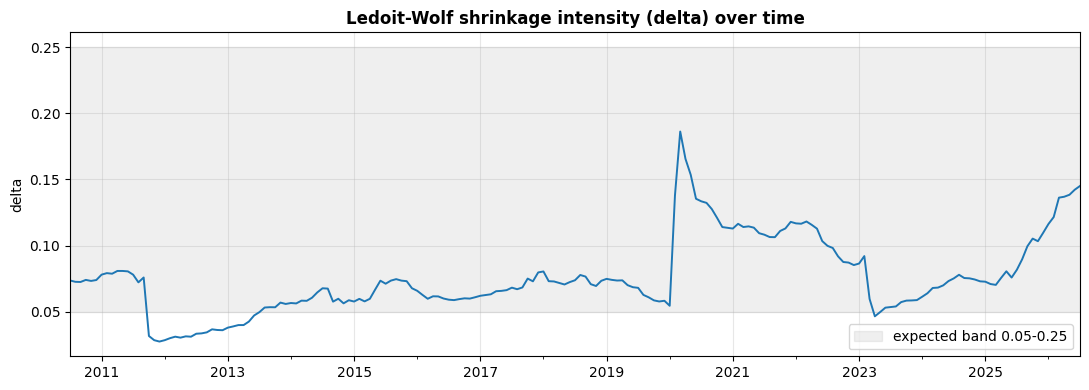

Highest-shrinkage month-ends (window most in need of structure):
  2020-03-31  delta=0.186
  2020-04-30  delta=0.166
  2020-05-31  delta=0.153
  2026-07-31  delta=0.145
  2026-06-30  delta=0.142


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
delta_ts.plot(ax=ax, color="#1f77b4", linewidth=1.4)
ax.axhspan(0.05, 0.25, color="grey", alpha=0.12, label="expected band 0.05-0.25")
ax.set_title("Ledoit-Wolf shrinkage intensity (delta) over time", fontweight="bold")
ax.set_ylabel("delta"); ax.set_xlabel(""); ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

top = delta_ts.nlargest(5)
print("Highest-shrinkage month-ends (window most in need of structure):")
for d, v in top.items():
    print(f"  {d.date()}  delta={v:.3f}")

### D2 — SPY–IEF correlation (stock–bond) from the sample matrices

The stock–bond correlation drives whether bonds diversify equities. Expected:
mostly **negative** 2010–2021 (bonds rally when stocks fall), flipping
**positive in 2022** (both fell together as rates spiked — real, not a bug),
possibly normalizing afterward.

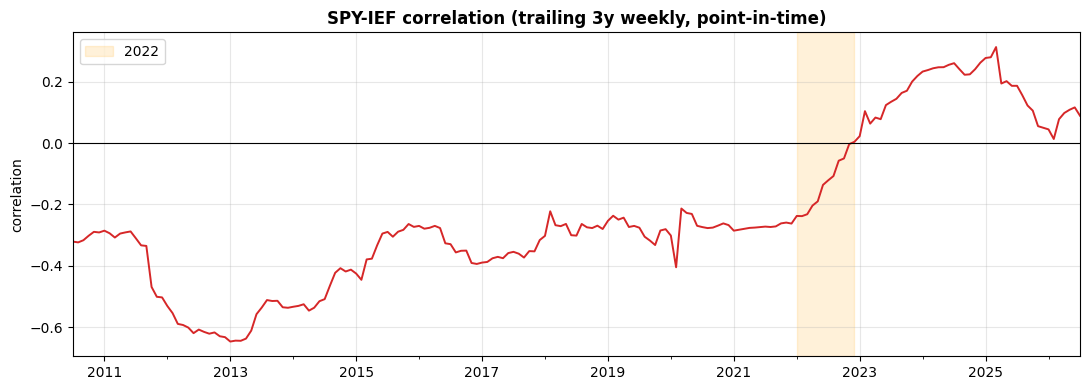

mean 2010-2021: -0.37   2022 range: -0.24 .. +0.00
latest (2026-07-31): +0.09


In [6]:
spy_ief = pd.Series(
    [cov_s[T].loc["SPY", "IEF"] /
     np.sqrt(cov_s[T].loc["SPY", "SPY"] * cov_s[T].loc["IEF", "IEF"]) for T in schedule],
    index=dates)

fig, ax = plt.subplots(figsize=(11, 4))
spy_ief.plot(ax=ax, color="#d62728", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           color="orange", alpha=0.15, label="2022")
ax.set_title("SPY-IEF correlation (trailing 3y weekly, point-in-time)", fontweight="bold")
ax.set_ylabel("correlation"); ax.set_xlabel(""); ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pre = spy_ief[spy_ief.index < "2022-01-01"]
y22 = spy_ief[(spy_ief.index >= "2022-01-01") & (spy_ief.index < "2023-01-01")]
print(f"mean 2010-2021: {pre.mean():+.2f}   2022 range: {y22.min():+.2f} .. {y22.max():+.2f}")
print(f"latest ({spy_ief.index[-1].date()}): {spy_ief.iloc[-1]:+.2f}")

### D3 — Average pairwise correlation among the 4 equity ETFs

Mean of the 6 pairwise correlations among {SPY, VEA, XLE, XLU}. Expected to
**spike toward 1 in stress** (2011, 2015–16, 2018, 2020, 2022): when everything
sells off together, intra-equity diversification collapses exactly when it is
most needed.

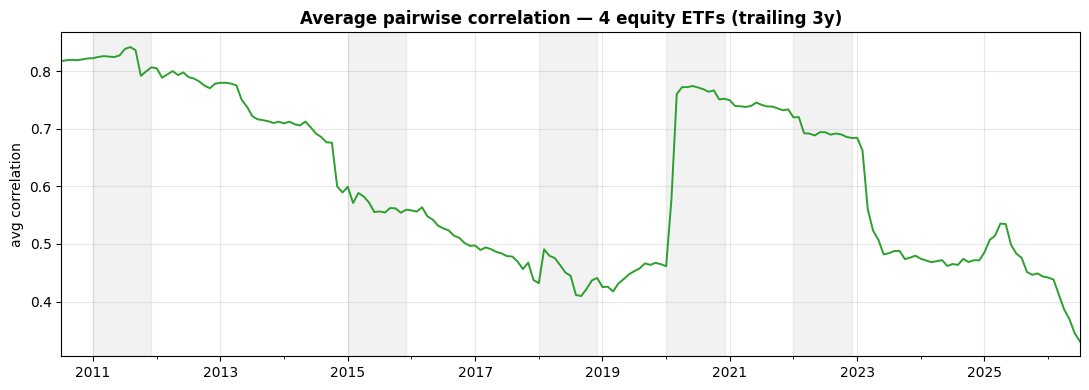

equity avg-corr: min=0.33 (2026-07-31)  max=0.84 (2011-08-31)


In [7]:
EQ = ["SPY", "VEA", "XLE", "XLU"]
iu = np.triu_indices(len(EQ), k=1)   # 6 unique pairs
eq_corr = pd.Series(
    [to_corr(cov_s[T]).loc[EQ, EQ].values[iu].mean() for T in schedule],
    index=dates)

fig, ax = plt.subplots(figsize=(11, 4))
eq_corr.plot(ax=ax, color="#2ca02c", linewidth=1.4)
for yr in ["2011", "2015", "2018", "2020", "2022"]:
    ax.axvspan(pd.Timestamp(f"{yr}-01-01"), pd.Timestamp(f"{yr}-12-31"),
               color="grey", alpha=0.10)
ax.set_title("Average pairwise correlation — 4 equity ETFs (trailing 3y)", fontweight="bold")
ax.set_ylabel("avg correlation"); ax.set_xlabel("")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"equity avg-corr: min={eq_corr.min():.2f} ({eq_corr.idxmin().date()})  "
      f"max={eq_corr.max():.2f} ({eq_corr.idxmax().date()})")

### D4 — Condition number: sample vs Ledoit-Wolf

Condition number = max/min eigenvalue. High = near-singular = unstable to invert
(the optimizer in step 5 inverts these). Expected: LW **lower and more stable**
because shrinkage lifts the small eigenvalues. Log scale.

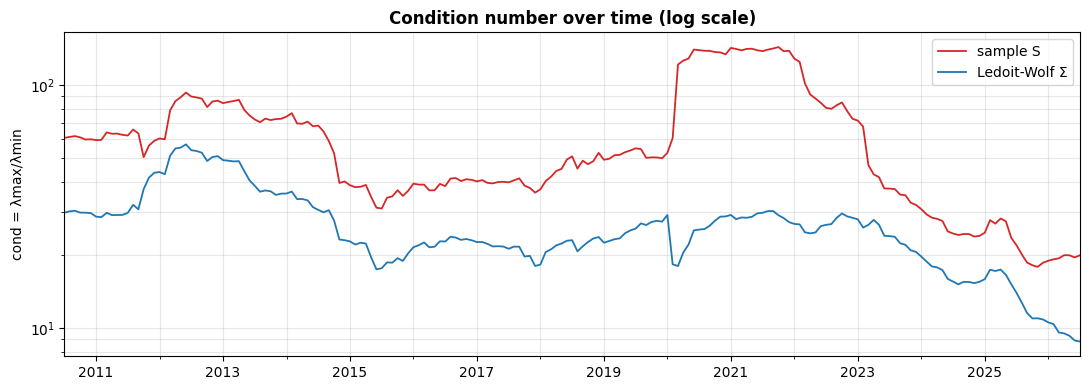

median condition number:  sample=50.9   LW=24.5


In [8]:
def cond(cov):
    ev = np.linalg.eigvalsh(cov.values)
    return ev.max() / ev.min()

cond_s = pd.Series([cond(cov_s[T]) for T in schedule], index=dates)
cond_l = pd.Series([cond(cov_l[T]) for T in schedule], index=dates)

fig, ax = plt.subplots(figsize=(11, 4))
cond_s.plot(ax=ax, label="sample S", color="#d62728", linewidth=1.3)
cond_l.plot(ax=ax, label="Ledoit-Wolf Σ", color="#1f77b4", linewidth=1.3)
ax.set_yscale("log")
ax.set_title("Condition number over time (log scale)", fontweight="bold")
ax.set_ylabel("cond = λmax/λmin"); ax.set_xlabel(""); ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median condition number:  sample={cond_s.median():.1f}   LW={cond_l.median():.1f}")

### D5 — Illustrative date: 2020-03-31 (COVID crash), S vs Σ

Correlation form, 2 decimals. Ledoit-Wolf shrinks toward a scaled identity, so
off-diagonal correlations are pulled **toward 0** — most where the sample
correlation is largest in magnitude. We list the biggest absolute changes.

In [9]:
T0 = pd.Timestamp("2020-03-31")
Cs, Cl = to_corr(cov_s[T0]), to_corr(cov_l[T0])

print(f"=== {T0.date()} : sample correlation (delta={deltas[T0]:.3f}) ===")
print(Cs.round(2).to_string())
print(f"\n=== {T0.date()} : Ledoit-Wolf correlation ===")
print(Cl.round(2).to_string())

diff = Cl - Cs
iu = np.triu_indices(len(OPT6), k=1)
changes = sorted(
    [(OPT6[a], OPT6[b], diff.values[a, b], Cs.values[a, b], Cl.values[a, b])
     for a, b in zip(*iu)],
    key=lambda x: abs(x[2]), reverse=True)
print("\nLargest absolute correlation changes from shrinkage (sample -> LW):")
for i, j, d, cs, cl in changes[:5]:
    print(f"  {i}-{j}: {cs:+.2f} -> {cl:+.2f}   (delta {d:+.2f})")

=== 2020-03-31 : sample correlation (delta=0.186) ===
Ticker   SPY   VEA   XLE   XLU   IEF   GLD
Ticker                                    
SPY     1.00  0.91  0.84  0.70 -0.21  0.31
VEA     0.91  1.00  0.87  0.67 -0.13  0.41
XLE     0.84  0.87  1.00  0.57 -0.23  0.36
XLU     0.70  0.67  0.57  1.00  0.19  0.52
IEF    -0.21 -0.13 -0.23  0.19  1.00  0.51
GLD     0.31  0.41  0.36  0.52  0.51  1.00

=== 2020-03-31 : Ledoit-Wolf correlation ===
      SPY   VEA   XLE   XLU   IEF   GLD
SPY  1.00  0.74  0.72  0.58 -0.10  0.23
VEA  0.74  1.00  0.74  0.55 -0.06  0.30
XLE  0.72  0.74  1.00  0.50 -0.11  0.28
XLU  0.58  0.55  0.50  1.00  0.09  0.40
IEF -0.10 -0.06 -0.11  0.09  1.00  0.21
GLD  0.23  0.30  0.28  0.40  0.21  1.00

Largest absolute correlation changes from shrinkage (sample -> LW):
  IEF-GLD: +0.51 -> +0.21   (delta -0.29)
  SPY-VEA: +0.91 -> +0.74   (delta -0.18)
  XLU-GLD: +0.52 -> +0.40   (delta -0.13)
  VEA-XLE: +0.87 -> +0.74   (delta -0.13)
  SPY-XLU: +0.70 -> +0.58   (delta -0.1

## Sanity notes (checklist for this step)

- **Weekly returns only** (rule 3); **6 optimizable assets**, SHY excluded.
- **Point-in-time**: every S_T / Σ_T uses data dated ≤ T only; outputs are stored
  per as-of date and not overwritten with recomputed history (rules 1–2).
- **Every Σ_T asserted symmetric and positive definite** (min eigenvalue > 0).
- **No optimization** here — these matrices are the input to Step 5.

Outputs written to `outputs/`: `cov_sample.parquet`, `cov_lw.parquet`,
`lw_delta.csv`.